In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

data = []
with open("dblp_dataset.jsonl", "r") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
df = df[
    (df["year"] > 1999) &
    (df["year"] < 2026)
]
df

,title,year,venue,dblp_key,query
0,Securing Data From Side-Channel Attacks: A Gra...,2024,IEEE Access,journals/access/AbbasOBSHAK24,side channel
1,Energy Efficient Obfuscation of Side-Channel L...,2024,SAC,conf/sac/Jin0C24,side channel
2,With Great Power Come Great Side Channels: Sta...,2024,USENIX Security Symposium,conf/uss/DunscheMEMBSS24,side channel
3,USENIX'24 Artifact Datasets: With Great Power ...,2024,Zenodo,data/11/DunscheMEMBSS24,side channel
4,Everything has its Bad Side and Good Side: Tur...,2023,IPSN,conf/ipsn/FengJAS23,side channel
...,...,...,...,...,...
3969,Countermeasures against Side-Channel Attacks f...,2001,IACR Cryptol. ePrint Arch.,journals/iacr/Bellezza01,side channel
3970,EMpowering Side-Channel Attacks.,2001,IACR Cryptol. ePrint Arch.,journals/iacr/RaoR01,side channel
3971,Side Channel Cryptanalysis of Product Ciphers.,2000,J. Comput. Secur.,journals/jcs/KelseySWH00,side channel
3972,Physical side-channel attacks on cryptographic...,2000,Softw. Focus,journals/sofo/Smart00,side channel


In [3]:
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["venue"] = df["venue"].fillna("")
df["has_venue"] = df["venue"].str.strip() != ""

all_counts = df.groupby("year").size().sort_index()
venue_counts = df[df["has_venue"]].groupby("year").size().sort_index()
cumulative = all_counts.cumsum()
smoothed = venue_counts.rolling(window=3, center=True).mean()
cumulative = venue_counts.cumsum()

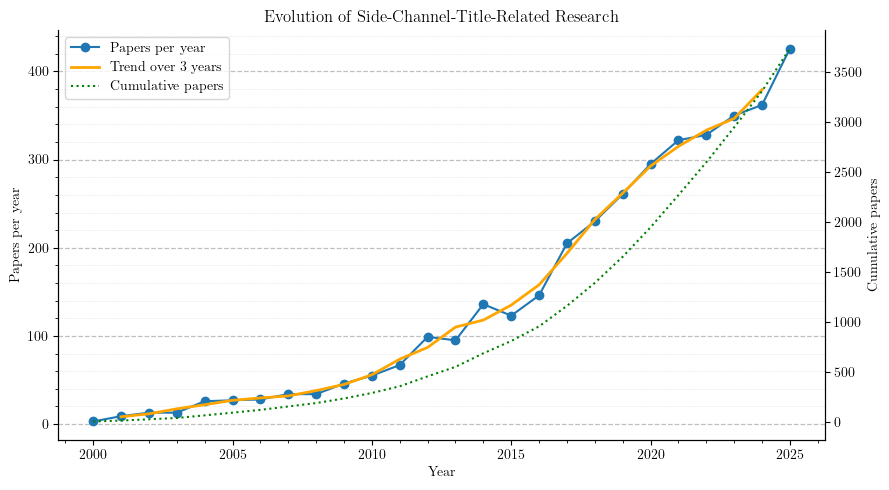

In [4]:
fig, ax1 = plt.subplots(figsize=(9,5))

# Left axis
ax1.plot(venue_counts.index, venue_counts.values, marker='o', label="Papers per year")
ax1.plot(smoothed.index, smoothed.values, linewidth=2, label="Trend over 3 years", color='orange')

ax1.set_xlabel("Year")
ax1.set_ylabel("Papers per year")

# Grid improvements
ax1.minorticks_on()
ax1.grid(True, which='major', axis='y', linestyle='--', linewidth=0.9, alpha=0.8)
ax1.grid(True, which='minor', axis='y', linestyle=':', linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)

# Right axis
ax2 = ax1.twinx()
ax2.plot(cumulative.index, cumulative.values, linestyle=':', label="Cumulative papers", color='green')
ax2.set_ylabel("Cumulative papers")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

# Clean look
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.title("Evolution of Side-Channel-Title-Related Research")
plt.tight_layout()
plt.savefig("side_channel_trend.pdf")
#plt.show()